# Entendimiento del negocio

En la industria de la música, saber de antemano si una canción será un éxito es muy importante para decidir en qué invertir. Por eso, crearmos un modelo que usa **regresión** para predecir qué tan popular será una canción, basándose solo en sus características de sonido. Para hacer esto, usamos la metodología **CRISP-DM**, que nos ayuda a enfocarnos en las necesidades del negocio desde el principio. Así, cada paso, desde limpiar los datos de Spotify hasta entrenar el modelo, está pensado para crear una herramienta útil y rentable, no solo un experimento. Primero limpiaremos y organizaremos estos datos, y luego entrenaremos modelos de Machine Learning que aprendan de los patrones históricos. Así, podremos responder a la pregunta: ¿se puede predecir si una canción será un éxito solo por cómo suena?

# Configuraciones iniciales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sentence_transformers import SentenceTransformer, util
import torch

# Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Constantes
SEED=30326271

# Entendimiento de los datos

## Carga de datos

In [ ]:
# Cargamos el dataset de Spotify
df = pd.read_csv('data/spotify_tracks.csv')

print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Descripcion del dataset

In [ ]:
print("=== DESCRIPCIÓN DEL DATASET ===")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}\n")

print("Tipos de datos por columna:")
print(df.dtypes)

=== DESCRIPCIÓN DEL DATASET ===
Número de filas: 114000
Número de columnas: 21

Tipos de datos por columna:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


Tenemos un conjunto de datos grande con 114,000 canciones y 21 tipos diferentes de información para cada una. Esto nos da mucha información para analizar y hacer predicciones. Podemos observar características del sonido, en este caso son la mayoría de las columnas, como la bailabilidad (danceability), energía (energy), volumen (loudness), etc. Estos son los detalles técnicos del sonido que usaremos para predecir la popularidad.

## Estadisticas de los datos

In [ ]:
# Filtrar solo las variables numéricas
variables_numericas = df.select_dtypes(include=[np.number]).drop(columns=['Unnamed: 0'], axis=1)

# Trasponer (.T) y seleccionar solo las métricas solicitadas
stats_df = variables_numericas.describe().T[['mean', '50%', 'std', 'min', 'max']]

# Renombrar las columnas para cumplir exactamente con lo pedido
stats_df.rename(columns={'mean': 'media', '50%': 'mediana', 'std': 'desv_estandar'}, inplace=True)

# Mostrar la tabla
stats_df

,media,mediana,desv_estandar,min,max
popularity,33.238535,35.000000,22.305078,0.000,100.000
duration_ms,228029.153114,212906.000000,107297.712645,0.000,5237295.000
danceability,0.566800,0.580000,0.173542,0.000,0.985
energy,0.641383,0.685000,0.251529,0.000,1.000
key,5.309140,5.000000,3.559987,0.000,11.000
loudness,-8.258960,-7.004000,5.029337,-49.531,4.532
mode,0.637553,1.000000,0.480709,0.000,1.000
speechiness,0.084652,0.048900,0.105732,0.000,0.965
acousticness,0.314910,0.169000,0.332523,0.000,0.996
instrumentalness,0.156050,0.000042,0.309555,0.000,1.000


Hay mucha variedad en las características de las canciones, como la popularidad, la duración y la energía. Los valores van desde muy bajos hasta muy altos, lo que es bueno porque el modelo tendrá diferentes tipos de datos para aprender y hacer predicciones. Las medias y medianas nos dan una idea de cómo es una canción típica en este conjunto. Por ejemplo, la duración promedio es de alrededor de 3.8 minutos y la popularidad promedio es de 33. También vimos que hay algunas canciones con valores muy extremos, como duraciones muy largas. Esto es algo que podríamos revisar más adelante para ver si afectan el modelo.

## Valores faltantes

In [ ]:
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df)) * 100
reporte = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})

# retornando un DataFrame ordenado de mayor a menor cantidad de nulos.
tabla_nulos =reporte.sort_values(by='Nulos', ascending=False)

tabla_nulos

,Nulos,Porcentaje (%)
artists,1,0.000877
track_name,1,0.000877
album_name,1,0.000877
Unnamed: 0,0,0.000000
track_id,0,0.000000
popularity,0,0.000000
duration_ms,0,0.000000
explicit,0,0.000000
danceability,0,0.000000
energy,0,0.000000


Como hay muy pocos valores faltantes y están en columnas que son más descriptivas y que probablemente no usaremos para hacer predicciones, la limpieza de datos será más fácil. No necesitaremos usar métodos complicados para llenar o arreglar muchos datos que faltan.
Podemos simplemente eliminar esas filas sin preocuparnos de perder información importante. Si alguna de esas columnas fuera muy importante, podríamos intentar rellenar los datos faltantes, pero en este caso, borrar las filas es la opción más simple y segura.



## Analisis de las distribución

Sabemos que $y \in \mathbb{R}^{n}$, donde cada valor $y_i \in [0, 100]$ representa la popularidad real de la canción $i$. Ahora visualizar la distribución de esta nos permitira observar su comportamiento y tomar desiciones en base a esto

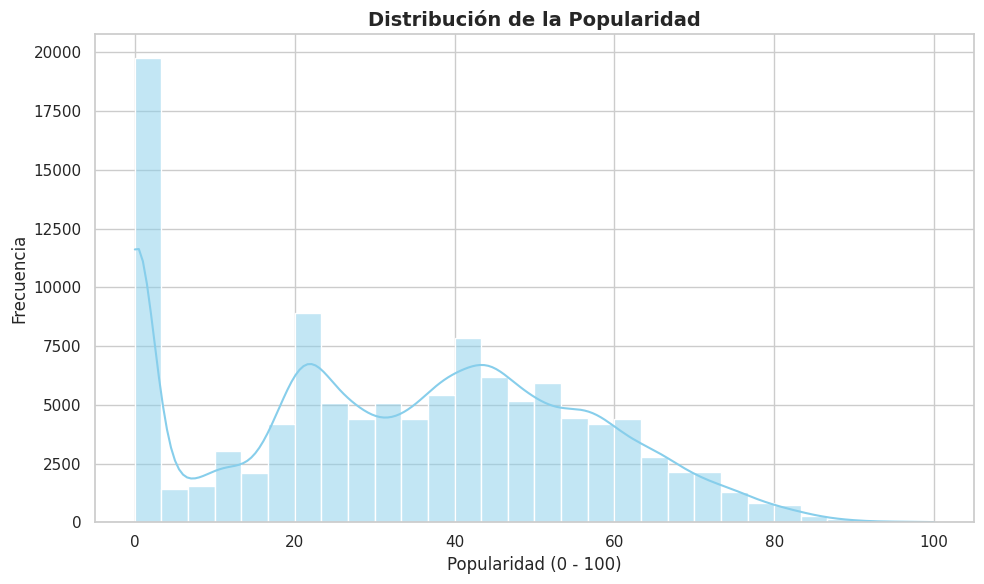

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=30, kde=True, color='skyblue')

plt.title('Distribución de la Popularidad', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad (0 - 100)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

La mayoría de las canciones en nuestro conjunto de datos tienen popularidad baja o media, lo cual es normal en la música. Hay muchas canciones con popularidad entre 0 y 50, y a medida que la popularidad sube, hay menos canciones. Esto quiere decir que la popularidad está concentrada en valores bajos, pero hay algunas canciones muy populares que son menos comunes. También hay un pico en popularidad 0, que puede ser porque son canciones nuevas o poco conocidas, y eso es normal. Es importante tener en cuenta esta forma de distribución cuando hagamos el modelo, ya que puede afectar cómo aprende a predecir. Por eso, podríamos usar técnicas especiales para manejar esta distribución desigual y obtener mejores resultados.

## Analisis de relacion entre variables

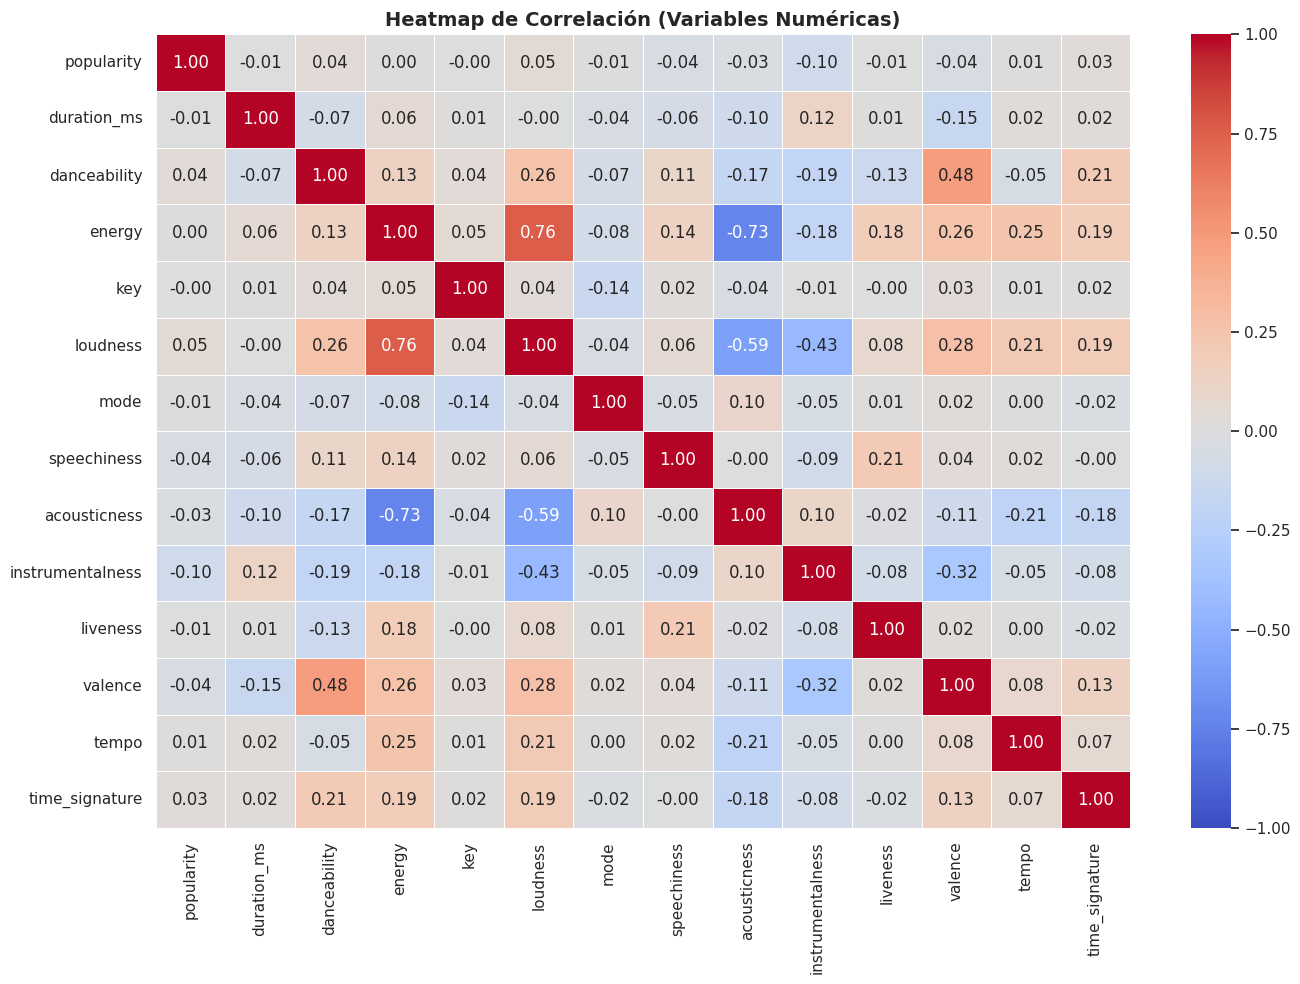

In [ ]:
#  Seleccionamos dinámicamente solo las columnas de tipo numérico (int, float)
variables_numericas = df.select_dtypes(include=[np.number]).drop(columns=['Unnamed: 0'], axis=1)

# Calculamos la matriz de correlación de Pearson
matriz_corr = variables_numericas.corr()


plt.figure(figsize=(14, 10))


sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Heatmap de Correlación (Variables Numéricas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El par de variables con mayor correlación es 'energy' y 'loudness'
Coeficiente de correlación: 0.7617



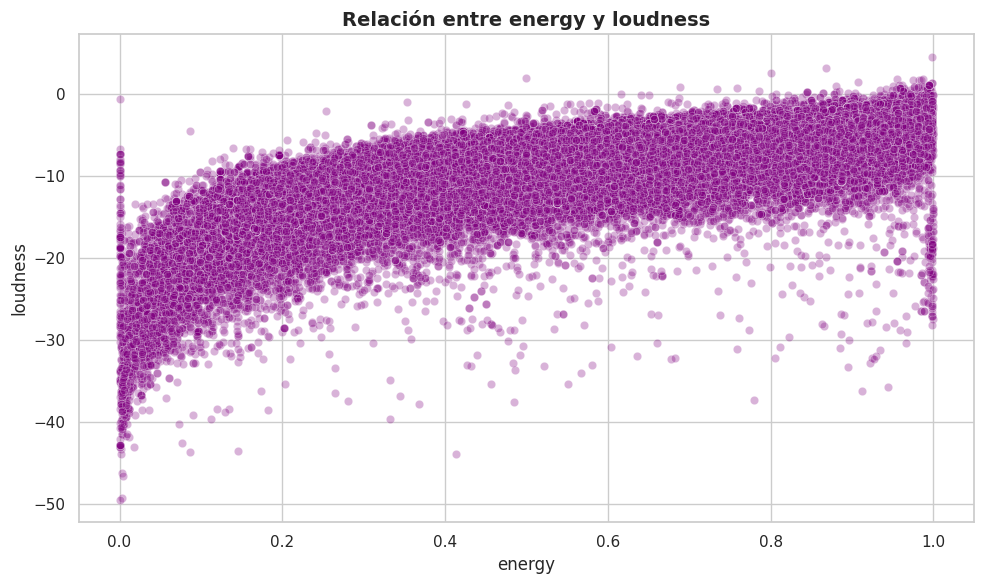

In [ ]:

# Excluimos la correlación de 1.0
corr_unstacked = matriz_corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

# Encontramos los nombres de las dos variables con la correlación más alta
var1, var2 = corr_unstacked.idxmax()
correlacion_max = matriz_corr.loc[var1, var2]

print(f"El par de variables con mayor correlación es '{var1}' y '{var2}'")
print(f"Coeficiente de correlación: {correlacion_max:.4f}\n")

# Generamos un gráfico de dispersión para ese par
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[var1], y=df[var2], alpha=0.3, color='purple')

plt.title(f'Relación entre {var1} y {var2}', fontsize=14, fontweight='bold')
plt.xlabel(var1)
plt.ylabel(var2)

plt.tight_layout()
plt.show()

Hemos visto que las variables "energy" (energía) y "loudness" (volumen) están muy relacionadas entre sí, con una alta correlación. Esto tiene sentido porque las canciones que son más enérgicas suelen ser también más ruidosas. Como estas dos características miden cosas parecidas, podríamos pensar en usar solo una para evitar repetir información en nuestro modelo.
Cuando miramos cómo se relaciona la popularidad con otras características, vemos que no hay una conexión fuerte y directa con ninguna en particular. Esto es normal en datos complejos, y significa que la popularidad depende de muchos factores juntos, no solo de uno.
También encontramos algunas relaciones negativas. Por ejemplo, las canciones que son más acústicas suelen tener menos energía y menos volumen, lo que también es lógico.

## Otros Patrones de Atributos según la Popularidad

Se busca encontrar otros posibles patrones existentes entre los datos, comparando el comportamiento de distintuos atributos de canciones con la popularidad que estas poseen.

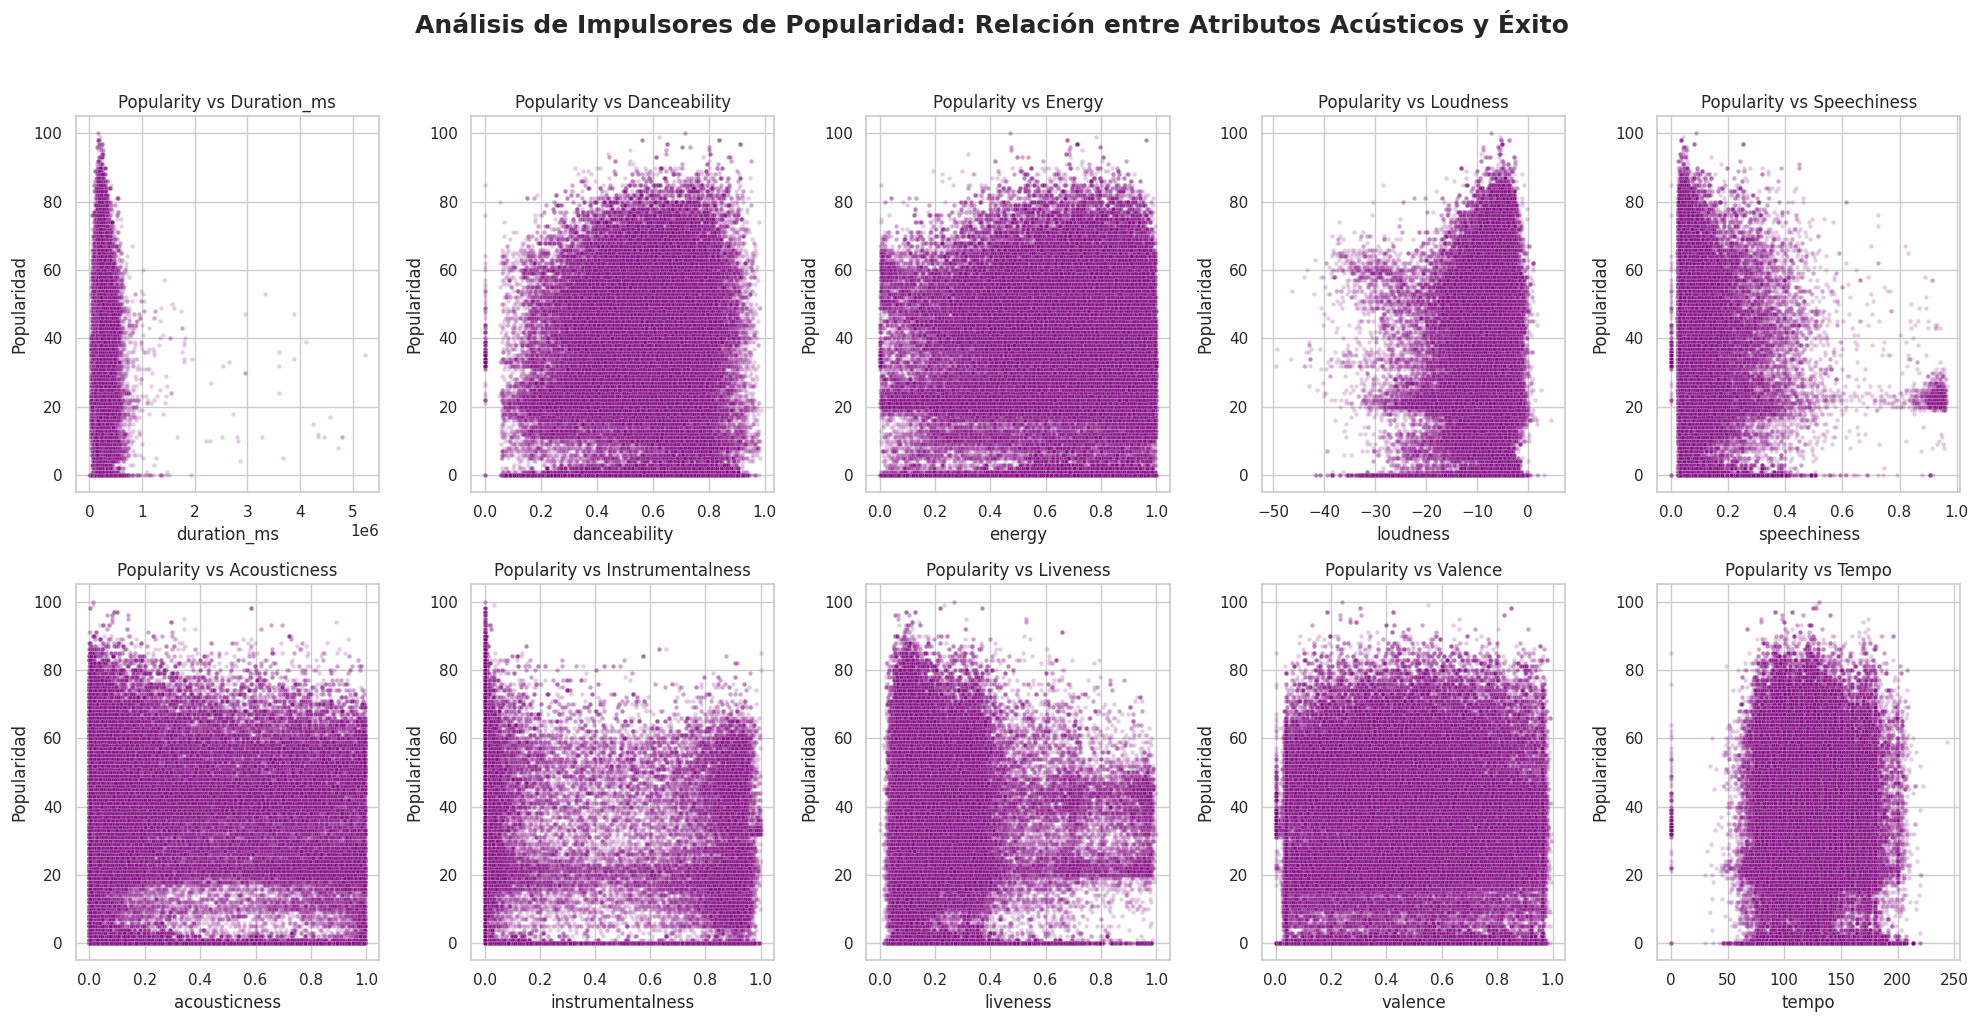

In [ ]:
# Definición de variables a contrastar con 'popularity'
variables_analisis = [
    'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]


fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
fig.suptitle('Análisis de Impulsores de Popularidad: Relación entre Atributos Acústicos y Éxito',
             fontsize=18, fontweight='bold', y=1.02)

# Aplanado de la matriz de ejes para iterar fácilmente
axes = axes.flatten()

for i, var in enumerate(variables_analisis):
    sns.scatterplot(
        data=df,
        x=var,
        y='popularity',
        ax=axes[i],
        alpha=0.2,
        color='purple',
        s=10
    )

    axes[i].set_title(f'Popularity vs {var.capitalize()}', fontsize=12)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Popularidad')

# Ajuste del espacio
plt.tight_layout()
plt.show()

Los gráficos anteriores revelan dónde está el consenso del mercado y cuáles son los patrones técnicos de los éxitos comerciales en Spotify. De esta forma, se agrupan los resultados en cuatro ítems:

- **Intensidad de la canción (Loudness y Energy):** Los temas que alcanzan un puntaje alto de popularidad pueden poseer distintos niveles de energía, pero muestran una tendencia a encontrarse en valores superiores a 0.5, mientras que el volumen muestra una concentración más clara entre -10 y 0 dB. Esto indica que el oyente promedio del mercado actual busca una experiencia sonora vibrante.

- **Estructura musical (Duration_ms e Instrumentalness):** El éxito de las canciones se desploma fuera del rango de 200000ms (aprox. 3 min), lo que muestra que canciones largas pierden popularidad. Además, se nota una barrera para temas sin voz, la popularidad masiva resida en valores cercanos a 0 en la escala de instrumentalidad.

- **Versatilidad Humana (Valence, Tempo y Danceability):** El éxito de las canciones parece ser indiferente a la velocidad de la canción o a si el sentimiento es triste o alegre. Por otro lado, aunque hay una ligera inclinación hacia temas bailables, existen éxitos en todo el espectro.

- **Autenticidad (Speechiness, Acosticness y Liveness):** El público muestra preferencia por niveles bajos de speechiness, valores altos (como podcasts o poermas) logran poca popularidad. Respecto a la acústica, se nota una muy ligera tendencia a canciones menos orgánicas. De la mano con esto, se aprecia que la mayoría de los éxitos son grabaciones de estudio, que presentan un liveness menor a 0.4.





# Preparación de los datos

### Experimento de Embedding

Esta parte es un análisis experimental para profundizar un poco más en lo que hemos visto y poder hacer comparaciones

In [ ]:
# Carga del modelo (este es ligero y multilingüe)
text_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:

# Definición de temas a probar
topics = {
    'party_distance': 'party celebration dance night out clubbing',
    'sadness_distance': 'sadness heartbreak lonely crying depression',
    'love_distance': 'romantic love relationship couple together'
}

# Preparación de los nombres de las canciones (limpiando el nulo detectado)
names = df['track_name'].fillna("Unknown").tolist()

# Generación de embeddings
print("Generando embeddings de texto... esto puede tardar un poco.")
embeddings_songs = text_model.encode(names, convert_to_tensor=True, show_progress_bar=True)

# Cálculo de distancias para cada tema
for nombre_col, frase_objetivo in topics.items():
    emb_objetivo = text_model.encode(frase_objetivo, convert_to_tensor=True)
    # Cálculo de la similitud de coseno
    similitudes = util.cos_sim(embeddings_songs, emb_objetivo)
    df[nombre_col] = similitudes.cpu().numpy()

print("Nuevas dimensiones añadidas")

Generando embeddings de texto... esto puede tardar un poco.


Batches:   0%|          | 0/3563 [00:00<?, ?it/s]

Nuevas dimensiones añadidas


In [ ]:
#--- Previsualización de resultados ---

# Selección del nombre de la canción y las nuevas columnas para comparar
preview_cols = ['track_name', 'party_distance', 'sadness_distance', 'love_distance']

print("Muestra aleatoria:")
df[preview_cols].sample(10)

Muestra aleatoria:


,track_name,party_distance,sadness_distance,love_distance
100972,Corazon De Oro,0.100298,0.105423,0.092582
5396,Resident Evil Rap,0.119993,0.074979,0.006514
19547,Long Live Cowgirls,0.136856,-0.024337,0.106734
75458,Autumn Colors,0.187738,0.088726,0.083472
74103,Sina,0.123337,0.180779,0.122190
10378,Song for Summer,0.269238,0.170314,0.195424
32467,The Finishing,0.180243,0.161644,0.097750
24622,Night,0.434302,0.047446,0.125047
103544,Let's Make Christmas Mean Something This Year ...,0.258657,0.105067,0.083190
35375,Voando Feito um Gavião,0.161830,0.047547,0.021016


In [ ]:
# Top 5 de cada categoría

print("--- Top 5 Canciones con mayor 'love_distance' ---\n")
print(df[['track_name', 'love_distance']].sort_values(by='love_distance', ascending=False).head(5))

print("\n\n--- Top 5 Canciones con mayor 'sadness_distance' ---\n")
print(df[['track_name', 'sadness_distance']].sort_values(by='sadness_distance', ascending=False).head(5))

print("\n\n--- Top 5 Canciones con mayor 'party_distance' ---\n")
print(df[['track_name', 'party_distance']].sort_values(by='party_distance', ascending=False).head(5))

--- Top 5 Canciones con mayor 'love_distance' ---

                     track_name  love_distance
90263           Amor de los dos       0.761608
15352               Love Affair       0.760012
103906              Love Affair       0.760012
90697   El amor es para los dos       0.755456
107302                romantics       0.731767


--- Top 5 Canciones con mayor 'sadness_distance' ---

                                  track_name  sadness_distance
45939                     Tristeza e Solidão          0.847848
6780   Travels to Sadness, Hate & Depression          0.818483
5468                      Sadness and Sorrow          0.817248
5174                      Sadness and Sorrow          0.817248
56320        this is what sadness feels like          0.785922


--- Top 5 Canciones con mayor 'party_distance' ---

                             track_name  party_distance
66125          Dance Party in the House        0.807558
13222                  Dance - Club Mix        0.790647
45319      

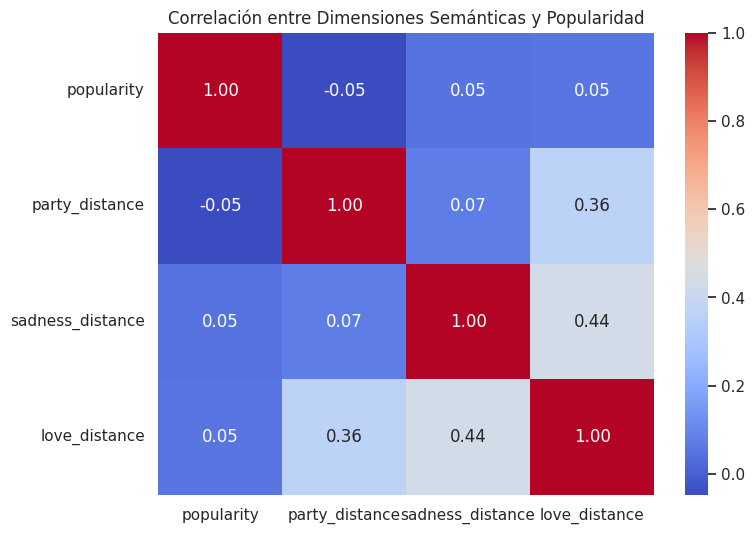

In [ ]:
# Matriz de correlación de las nuevas dimensiones con la popularidad

cols_to_corr = ['popularity', 'party_distance', 'sadness_distance', 'love_distance']

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Dimensiones Semánticas y Popularidad')
plt.show()

De esta analisis se pudo observar lo siguiente

- El modelo paraphrase-multilingual-MiniLM-L12-v2 hizo un buen trabajo. En las impresiones del top 5 se puede apreciar que identificó términos en español, inglés y portugués. También detectó sinónimos.

- Las tres dimensiones tienen una relación lineal muy baja con la popularidad. Esto significa que el nombre de la canción por sí solo no predice el éxito.

- La correlación más alta de la matriz es 0.44, entre sadness_distance y love_distance. Esto indica una mezcla de sentimientos, sugiriendo que en la música el amor y la tristeza van de la mano (canciones de desamor).

**Nota**: Para probar el modelo estas columnas, se hace una segunda corrida en la sección respectiva.

## Limpieza estructural

In [ ]:
# Eliminar filas con valores nulos
df_clean = df.dropna()

# Eliminar variables de identificación y texto libre
columnas_a_eliminar = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'key']
df_clean = df_clean.drop(columns=columnas_a_eliminar)

print(f"Dimensiones tras la limpieza: {df_clean.shape}")

Dimensiones tras la limpieza: (113999, 17)


El primer paso es asegurarnos de que los datos estén completos y bien organizados. Los algoritmos de regresión no pueden trabajar con datos que tengan valores faltantes, porque eso causa errores. Por eso, eliminamos las filas que no tienen toda la información. También quitamos columnas que no ayudan a predecir, como los IDs o los nombres de las canciones. Ademas removemos la columna genero para simplicidad del modelo. Estos datos de texto no aportan nada al modelo de regresión y solo podrían causar problemas o usar memoria de más.

## Transformación funcional

In [ ]:
# Convertir booleano (True/False) a binario (1/0)
df_clean['explicit'] = df_clean['explicit'].astype(int)
df_clean

,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,party_distance,sadness_distance,love_distance
0,73,230666,0,0.676,0.4610,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,0.286376,0.145630,0.123285
1,55,149610,0,0.420,0.1660,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,0.242919,0.154402,0.038028
2,57,210826,0,0.438,0.3590,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,0.056722,0.114244,0.081627
3,71,201933,0,0.266,0.0596,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,0.143272,0.456884,0.445157
4,82,198853,0,0.618,0.4430,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,0.164627,0.088801,0.158156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0,0.172,0.2350,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,0.100990,0.113816,0.135514
113996,22,385000,0,0.174,0.1170,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,0.033319,0.026265,0.093926
113997,22,271466,0,0.629,0.3290,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,0.185604,0.244497,0.242068
113998,41,283893,0,0.587,0.5060,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,0.291240,0.224024,0.288912


Los modelos de regresión lineal necesitan que todos los datos de entrada sean números. Por eso, convertimos la variable "explicit", que es de tipo verdadero/falso, en números 0 y 1 para que el modelo pueda usarla.

### Tratamiento de Sesgo y de Valores Atípicos / Outliers

In [ ]:
# Tratamiento de Sesgo

dimensiones_antes = df_clean.shape[0]

# Separamos el dataset en dos grupos: Popularidad 0 y Popularidad > 0
df_ceros = df_clean[df_clean['popularity'] == 0]
df_resto = df_clean[df_clean['popularity'] > 0]

# Aplicamos Undersampling: Conservamos solo el 5% de las canciones con popularidad 0
df_ceros_reducido = df_ceros.sample(frac=0.12, random_state=SEED)

# Volvemos a concatenar (unir) ambos grupos y mezclamos las filas aleatoriamente
df_clean = pd.concat([df_ceros_reducido, df_resto]).sample(frac=1, random_state=SEED).reset_index(drop=True)

dimensiones_despues = df_clean.shape[0]
canciones_eliminadas = dimensiones_antes - dimensiones_despues

print(f"Canciones con popularidad 0 originales: {len(df_ceros)}")
print(f"Canciones con popularidad 0 conservadas: {len(df_ceros_reducido)}")
print(f"Total de canciones eliminadas para balancear: {canciones_eliminadas}")
print(f"Nuevas dimensiones del dataset: {df_clean.shape}")

Canciones con popularidad 0 originales: 16019
Canciones con popularidad 0 conservadas: 1922
Total de canciones eliminadas para balancear: 14097
Nuevas dimensiones del dataset: (99902, 17)


Al ver la distribución de la popularidad, notamos que hay muchas canciones con popularidad cero. Esto puede ser porque son canciones nuevas o poco conocidas, y eso es normal. Pero como esto puede afectar el rendimiento del modelo, preferimos eliminar la mayoria de lo casos que tienen popularidad cero porque el modelo podría aprender demasiado sobre esos casos de cero popularidad y no aprender bien a diferenciar entre canciones con popularidad baja, media o alta. Es como si el modelo se "concentrara" mucho en predecir ceros y no en entender bien las diferencias en el resto de las canciones. Esto puede hacer que el modelo no funcione bien para predecir canciones que sí tienen algo de popularidad.

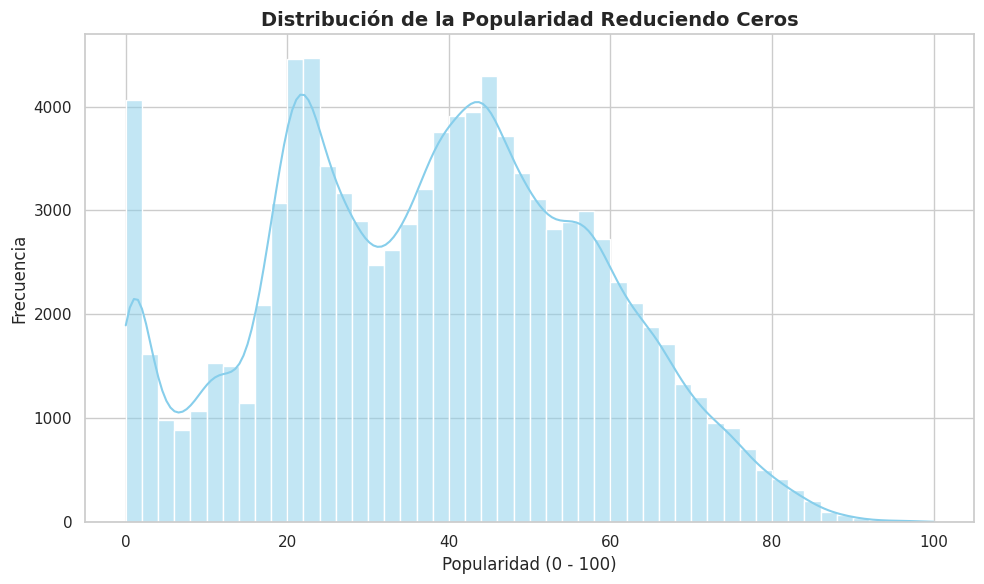

In [ ]:
# Gráfico para visualizar la distribución resultante luego del Tratamiento del Sesgo
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['popularity'], bins=50, kde=True, color='skyblue')

plt.title('Distribución de la Popularidad Reduciendo Ceros', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad (0 - 100)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

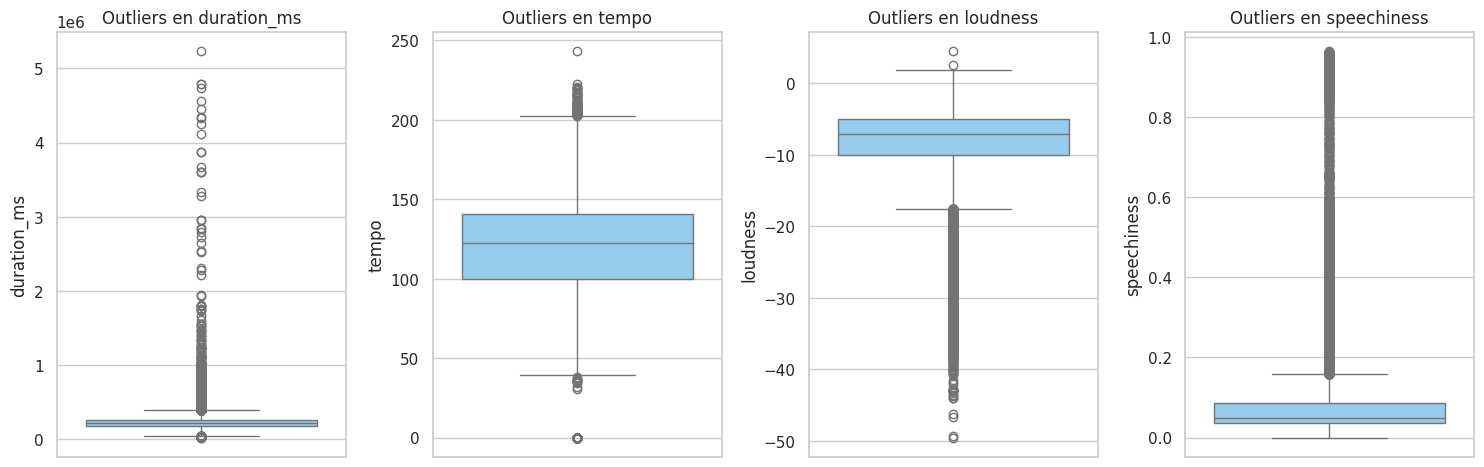

In [ ]:
# Para hacer una lámina de Valores Atípicos

variables_outliers = ['duration_ms', 'tempo', 'loudness', 'speechiness']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_outliers):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df_clean[var], color='lightskyblue')
    plt.title(f'Outliers en {var}')

plt.tight_layout()
plt.show()

Registros originales: 99902
Registros tras limpieza de outliers: 97500
Porcentaje mantenido: 97.60%


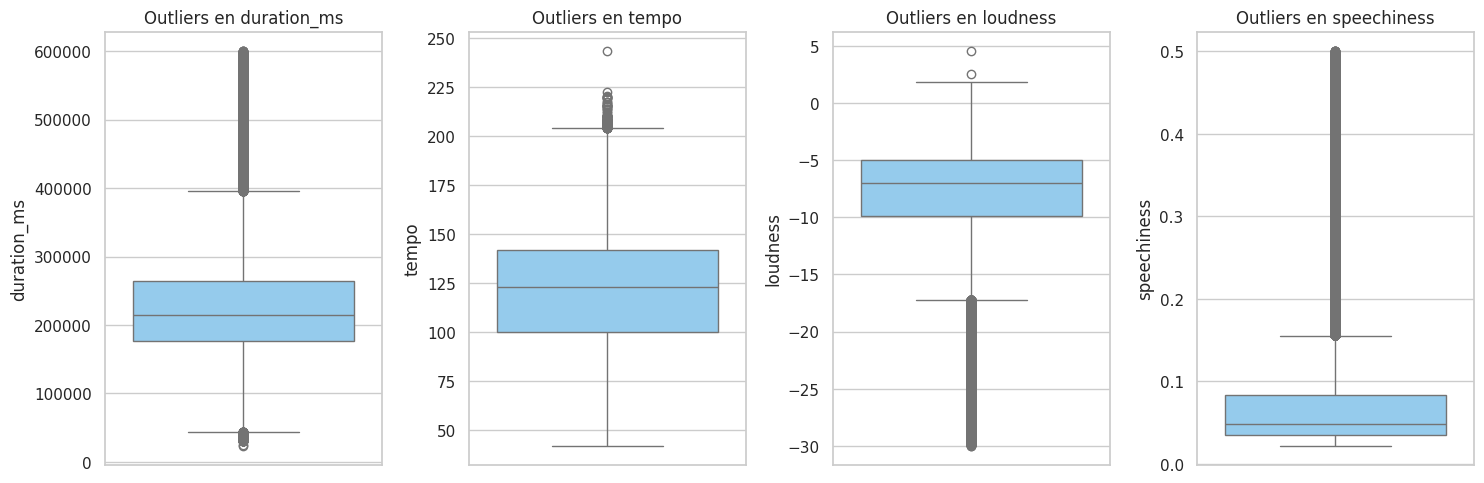

In [ ]:

df_filtered = df_clean.copy()

# Filtro de duración para eliminar tracks de más de 10min (600000ms), ya que serán podcats o similares
df_filtered = df_filtered[df_filtered['duration_ms'] <= 600000]

# Filtro de Loudness para eliminar volúmenes muy bajos (<-30 dB)
df_filtered = df_filtered[df_filtered['loudness'] >= -30]

# Filtro de Speechiness para eliminar tracks con más de 0.5 de contenido hablado, serán libros o poemas
df_filtered = df_filtered[df_filtered['speechiness'] <= 0.5]

# Filtro de Tempo para eliminar tracks con tempo casi inexistente (< 40 BPM)
df_filtered = df_filtered[df_filtered['tempo'] >= 40]

print(f"Registros originales: {len(df_clean)}")
print(f"Registros tras limpieza de outliers: {len(df_filtered)}")
print(f"Porcentaje mantenido: {len(df_filtered)/len(df_clean)*100:.2f}%")


variables_outliers = ['duration_ms', 'tempo', 'loudness', 'speechiness']

plt.figure(figsize=(15, 5))

for i, var in enumerate(variables_outliers):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df_filtered[var], color='lightskyblue')
    plt.title(f'Outliers en {var}')

plt.tight_layout()
plt.show()

### Manejo de multicolinealidad

Variable eliminada por alta multicolinealidad: ['loudness']
Nuevas dimensiones del dataset: (97500, 16)


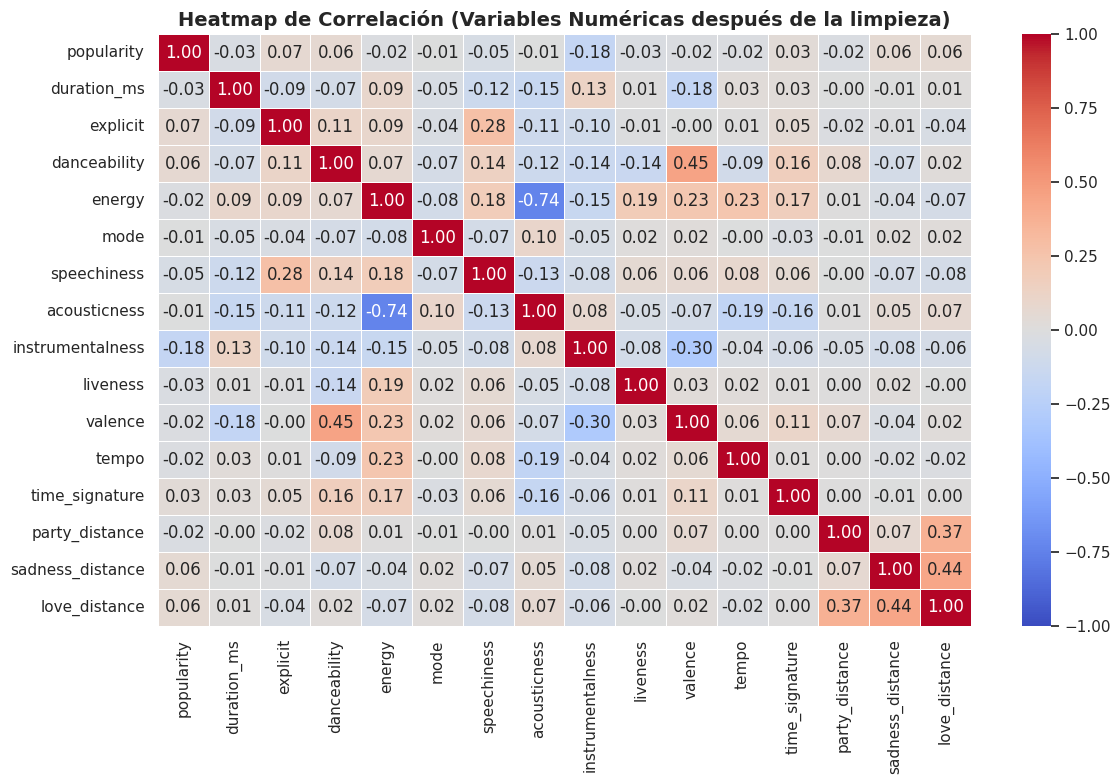

In [ ]:
# Decidimos conservar 'energy' (va de 0 a 1) y eliminar 'loudness' (decibelios).
columnas_correlacionadas = ['loudness']

# Eliminamos la variable redundante
df_clean_corr = df_filtered.drop(columns=columnas_correlacionadas)

print(f"Variable eliminada por alta multicolinealidad: {columnas_correlacionadas}")
print(f"Nuevas dimensiones del dataset: {df_clean_corr.shape}")


matriz_corr_clean = df_clean_corr.corr()

#  Generamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr_clean, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap de Correlación (Variables Numéricas después de la limpieza)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Como vimos en el análisis de la correlación, notamos que las variables "energy" y "loudness" están muy relacionadas. Por eso, decidimos quitar "loudness" porque con una de las dos se puede representar la información de ambas. Viendo el grafico podemos ver como hay relaciones mas independientes entre si. Tambien noten que la relcion entre "key" y popularidad es cero, lo que nos da una idea de que el tono de una cancion no influye en su popularidad

## Particion de los datos

In [ ]:
# Separar la matriz de características (X) y el vector objetivo (y)
df_model = df_clean_corr.copy()
X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

#Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
scaler = StandardScaler()

# fit_transform solo en entrenamiento, transform en prueba para evitar Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos de entrenamiento (X_train): {X_train.shape[0]} canciones")
print(f"Datos de prueba (X_test): {X_test.shape[0]} canciones")

Datos de entrenamiento (X_train): 78000 canciones
Datos de prueba (X_test): 19500 canciones


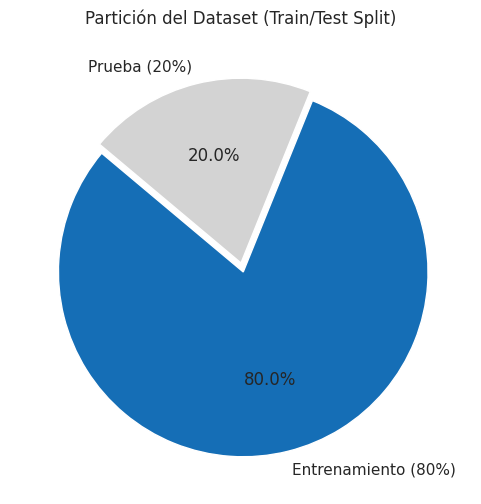

In [ ]:
# Gráfico para mostrar la Partición de Datos

labels = ['Entrenamiento (80%)', 'Prueba (20%)']
sizes = [80, 20]
colors = ['#156eb6', '#d3d3d3']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
plt.title('Partición del Dataset (Train/Test Split)')
plt.show()

# Modelado y Evaluacion

## Regresión lineal: definición

La regresión lineal es un modelo estadístico que busca modelar la relación lineal entre una variable dependiente $Y$ y una o más variables independientes $X$. En forma matricial, esto se representa como:

$$
Y = X\beta + \varepsilon
$$

donde:

1. $Y$ es el vector de variables dependientes.
1. $X$ es la matriz de variables independientes.
1. $\beta$ es el vector de coeficientes.
1. $\varepsilon$ es el vector de errores.

### El problema a resolver

 El objetivo de la regresión lineal es encontrar el "mejor" vector de coeficientes $\beta$ que logre que las predicciones $\hat{Y} = X\beta$ se acerquen lo más posible a los valores reales $Y$. En esencia, buscamos la línea (o hiperplano) que mejor se ajuste a la nube de puntos de los datos.

### Función de optimización (Función de costo)

Para medir qué tan "bueno" es nuestro ajuste, definimos una función de pérdida. El método más común es el de Mínimos Cuadrados Ordinarios (OLS), donde se busca minimizar la Suma de los Cuadrados de los Residuos (SSR) o, equivalentemente, el Error Cuadrático Medio (MSE). La función objetivo $J(\beta)$ que queremos optimizar es:

$$J(\beta) = \min_{\beta} \| Y - X\beta \|^2$$O expresada de forma expandida para $n$ muestras:$$MSE(\beta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - x_i^\top \beta)^2$$

#### **El objetivo**
El problema se resuelve encontrando el valor de $\beta$ que minimiza esta función:
  - **Analíticamente**: Mediante la Ecuación Normal $\beta = (X^\top X)^{-1} X^\top Y$.
  - **Numéricamente**: Mediante algoritmos de optimización como el Gradiente Descendiente.

## Entrenamiento del modelo

In [ ]:

# Regresión Lineal Clásica
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

# Generar predicciones con los datos de prueba
y_pred_lr = modelo_lr.predict(X_test_scaled)


# Calculamos el RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculamos el R2 Score
r2_lr = r2_score(y_test, y_pred_lr)

print("=== RESULTADOS DE EVALUACIÓN ===")
print(f"REGRESIÓN LINEAL CLÁSICA - RMSE: {rmse_lr:.4f} | R2: {r2_lr:.4f}")

=== RESULTADOS DE EVALUACIÓN ===
REGRESIÓN LINEAL CLÁSICA - RMSE: 19.2854 | R2: 0.0566


## Evaluación del modelo

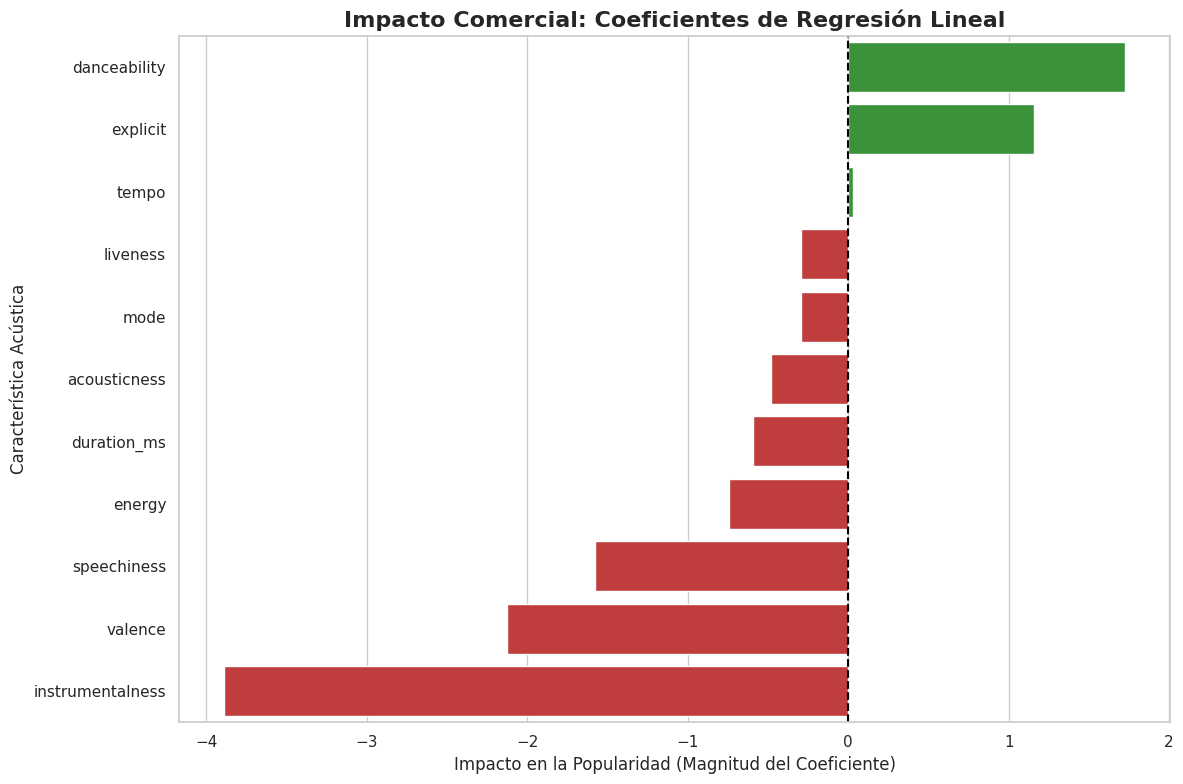

=== INTERPRETACIÓN COMERCIAL ===
La característica que MÁS SUMA a la popularidad es: 'danceability'
La característica que MÁS RESTA a la popularidad es: 'instrumentalness'


In [ ]:

# Seleccionamos las variables principales para enfocarnos en las métricas de audio
columnas_principales = X.columns[:11]

# Extraer los coeficientes correspondientes
coef_lr = modelo_lr.coef_[:11]


df_coeficientes = pd.DataFrame({
    'Variable': columnas_principales,
    'Magnitud del Coeficiente': coef_lr
})

#  Ordenar los valores de MAYOR a MENOR basándonos en el impacto
df_coeficientes = df_coeficientes.sort_values(by='Magnitud del Coeficiente', ascending=False)


plt.figure(figsize=(12, 8))


colores = ['#2ca02c' if valor > 0 else '#d62728' for valor in df_coeficientes['Magnitud del Coeficiente']]

sns.barplot(data=df_coeficientes, x='Magnitud del Coeficiente', y='Variable', palette=colores)


plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.title('Impacto Comercial: Coeficientes de Regresión Lineal', fontsize=16, fontweight='bold')
plt.xlabel('Impacto en la Popularidad (Magnitud del Coeficiente)', fontsize=12)
plt.ylabel('Característica Acústica', fontsize=12)

plt.tight_layout()
plt.show()


print("=== INTERPRETACIÓN COMERCIAL ===")
variable_top = df_coeficientes.iloc[0]['Variable']
variable_bottom = df_coeficientes.iloc[-1]['Variable']
print(f"La característica que MÁS SUMA a la popularidad es: '{variable_top}'")
print(f"La característica que MÁS RESTA a la popularidad es: '{variable_bottom}'")

Al mirar la gráfica de coeficientes, vemos números positivos y negativos. Los números positivos nos muestran qué cosas hacen que una canción tenga éxito; por ejemplo, si tiene más ritmo bailable o energía, eso ayuda a que suba en las listas.
Por otro lado, los números negativos son señales de alerta. Nos dicen qué características no le gustan a la mayoría de la gente. Por ejemplo, si el coeficiente de "instrumentalness" (que indica si la canción es solo instrumental, sin voces) es muy negativo, quiere decir que para que la canción sea un éxito mundial y rentable, el artista debería incluir voces, porque el público generalmente prefiere canciones con letras y canta junto.

### Modelo experimental: Dimensiones adicionales

In [ ]:
# Creamos df_temas seleccionando solo las columnas nuevas que acabas de calcular
columnas_nuevas = ['party_distance', 'sadness_distance', 'love_distance']
df_temas = df[columnas_nuevas]

# Eliminamos las columnas si ya existen para evitar el conflicto
df_clean_corr = df_clean_corr.drop(columns=['party_distance', 'sadness_distance', 'love_distance'], errors='ignore')


df_completo_v2 = df_clean_corr.join(df_temas)

# Ahora sí, procedemos con la lógica de V2
df_v2 = df_completo_v2.copy()

# Definir X_v2 incluyendo las nuevas dimensiones
X_v2 = df_v2.drop(columns=['popularity'])
y_v2 = df_v2['popularity']

# Dividir usando la MISMA semilla para que las canciones sean las mismas
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=SEED
)

# Escalar los nuevos datos
scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_v2)
X_test_scaled_v2 = scaler_v2.transform(X_test_v2)

print(f"V2: Ahora entrenamos con {X_v2.shape[1]} características (antes eran {X.shape[1]})")

V2: Ahora entrenamos con 15 características (antes eran 15)


In [ ]:
# Entrenar Modelo V2
modelo_lr_v2 = LinearRegression()
modelo_lr_v2.fit(X_train_scaled_v2, y_train_v2)

# Generar predicciones
y_pred_lr_v2 = modelo_lr_v2.predict(X_test_scaled_v2)

# Calcular métricas
rmse_lr_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_lr_v2))
r2_lr_v2 = r2_score(y_test_v2, y_pred_lr_v2)

print("=== RESULTADOS V2 (Nuevas Dimensiones) ===")
print(f"RMSE: {rmse_lr_v2:.4f} | R2: {r2_lr_v2:.4f}")

=== RESULTADOS V2 (Nuevas Dimensiones) ===
RMSE: 19.3202 | R2: 0.0532


In [ ]:
# Comparativa rápida
comparativa = pd.DataFrame({
    'Métrica': ['RMSE', 'R2'],
    'Modelo V1 (Base)': [rmse_lr, r2_lr], # Asumiendo que guardaste los de la V1
    'Modelo V2 (Atributos Textuales)': [rmse_lr_v2, r2_lr_v2]
})

print(comparativa)

  Métrica  Modelo V1 (Base)  Modelo V2 (Atributos Textuales)
0    RMSE         19.285396                        19.320173
1      R2          0.056633                         0.053227


El modelo tuvo un rendimiento un poco peor. Esto puede ser por varias razones:

- **Poca relación directa**: La regresión lineal busca una conexión clara, como "más amor, más popularidad". Pero en la música no siempre es así. Una canción de amor puede ser un éxito o un fracaso.

- **Ruido en los títulos**: Solo se usó el nombre de la canción para el análisis, no la letra completa. El título no siempre refleja de qué trata la canción. Por ejemplo, una canción llamada "Luna" puede ser de fiesta, romántica o triste.

- **La popularidad depende de muchas cosas**: En Spotify, la popularidad depende de factores que no están en los datos usados, como:
  - El marketing y dinero que hay detrás del artista.
  - Si la canción aparece en listas populares.
  - La viralidad en redes sociales como TikTok.

# Despliegue

In [ ]:

columnas_entrenamiento = X.columns

def predecir_exito_musical(nuevos_datos, modelo, scaler, columnas_esperadas):
    """
    Pipeline completo que recibe un dataset crudo de Spotify, aplica todo
    el preprocesamiento automático y devuelve las predicciones de popularidad.
    """

    df_pipeline = nuevos_datos.copy()


    # Lista de columnas a eliminar (incluimos 'popularity' por si viene en el dataset de prueba)
    cols_a_eliminar = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_genre', 'key',
                       'track_name', 'loudness', 'popularity']


    # Eliminamos solo las columnas que realmente existan en este nuevo dataset
    cols_presentes = [col for col in cols_a_eliminar if col in df_pipeline.columns]
    df_pipeline = df_pipeline.drop(columns=cols_presentes)

    # TRANSFORMACIÓN FUNCIONAL (Codificación)
    if 'explicit' in df_pipeline.columns:
        df_pipeline['explicit'] = df_pipeline['explicit'].astype(int)



    # Garantiza que el nuevo dataset tenga exactamente las mismas columnas que el entrenamiento.
    df_pipeline = df_pipeline.reindex(columns=columnas_esperadas, fill_value=0)


    # Usamos transform() y NO fit_transform(), porque debemos usar la escala original
    X_nuevo_escalado = scaler.transform(df_pipeline)


    predicciones = modelo.predict(X_nuevo_escalado)

    return np.round(predicciones, 2)

print("Pipeline construido exitosamente. Listo para recibir nuevos datasets.")

Pipeline construido exitosamente. Listo para recibir nuevos datasets.


## Simulación

In [ ]:
print("\n=== SIMULANDO LLEGADA DE NUEVAS CANCIONES ===")

# Simulamos tomar 5 canciones "crudas" del dataset original (como si fueran nuevas)
dataset_nuevas_canciones = df.sample(n=5, random_state=SEED)

# Pasamos el dataset crudo por nuestra función constructora
predicciones_exito = predecir_exito_musical(
    nuevos_datos=dataset_nuevas_canciones,
    modelo=modelo_lr,            # modelo de Regresión Lineal ya entrenado
    scaler=scaler,               # StandardScaler ya ajustado
    columnas_esperadas=columnas_entrenamiento
)


resultados_demo = pd.DataFrame({
    'Canción': dataset_nuevas_canciones['track_name'].values,
    'Artista': dataset_nuevas_canciones['artists'].values,
    'Popularidad Real': dataset_nuevas_canciones['popularity'].values,
    'Popularidad Predicha': predicciones_exito
})

# Agregamos una columna que calcule la diferencia absoluta
resultados_demo['Margen de Error Absoluto'] = abs(resultados_demo['Popularidad Real'] - resultados_demo['Popularidad Predicha'])

resultados_demo


=== SIMULANDO LLEGADA DE NUEVAS CANCIONES ===


,Canción,Artista,Popularidad Real,Popularidad Predicha,Margen de Error Absoluto
0,Solo,Clean Bandit;Demi Lovato,5,43.22,38.22
1,Mich hat ein Engel geküsst,Mickie Krause,0,34.08,34.08
2,Tritonia - Intro,Tritonal,20,29.99,9.99
3,Love Till It's Over (feat. MKLA),DVBBS;MKLA,57,47.12,9.88
4,Adadada Arrambame,Yuvan Shankar Raja;Shankar Mahadevan,49,36.13,12.87


# Conclusion

Después de analizar los datos de Spotify, vimos que la popularidad de una canción es muy compleja y no depende solo de sus características técnicas. Limpiamos y preparamos bien los datos para asegurar su calidad. Encontramos que las canciones más populares suelen ser las más bailable y con más energía, mientras que las muy instrumentales no tienen tanto éxito. Probamos un modelo para predecir la popularidad, pero no fue muy preciso, y agregar información del título no mejoró los resultados. Esto muestra que el nombre de la canción no es suficiente para predecir su éxito. En conclusión, aunque el modelo no puede predecir con certeza qué canciones serán grandes éxitos, sí ayuda a identificar aquellas con bajo potencial, lo que puede ser útil para tomar mejores decisiones en marketing y promoción.